In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px

import plotly.graph_objects as go

from sklearn.preprocessing import LabelEncoder

In [9]:
df = pd.read_csv("C:\\AI-Powered-Intelligent-Traffic-Management-System\\datasets\\processed\\Metro_Interstate_Traffic_Volume.csv")
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [10]:
print("="*60)
print("Dataset Preview")
print("="*60)

df.head()

Dataset Preview


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [12]:
print(df.shape)

(48204, 9)


In [13]:
print(df.isnull().sum())

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


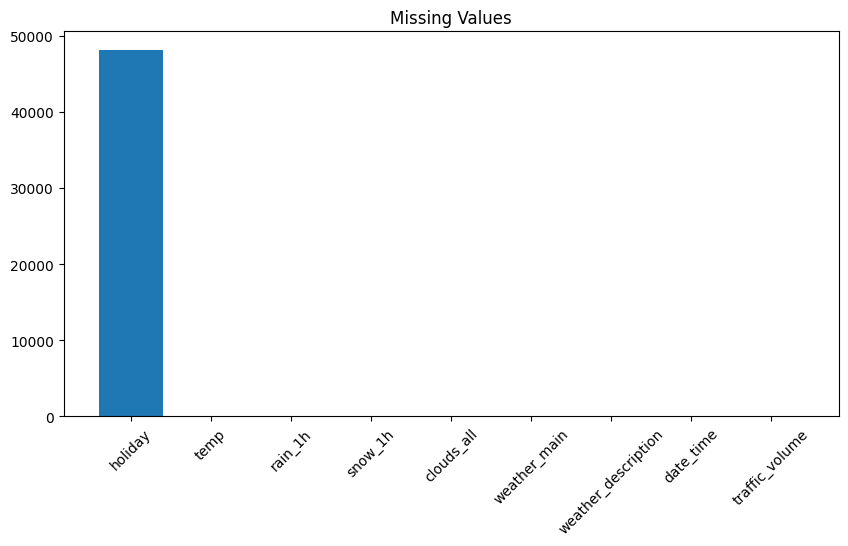

In [14]:
missing = df.isnull().sum()

plt.figure(figsize=(10,5))

plt.bar(
    missing.index,
    missing.values
)

plt.xticks(rotation=45)

plt.title("Missing Values")

plt.show()

In [15]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 17


In [16]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [18]:
print(df.columns.tolist())

['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']


In [19]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv(
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\datasets\processed\Metro_Interstate_Traffic_Volume.csv"
)

print("="*70)
print("Original Dataset Shape")
print(df.shape)

print("\nDataset Columns")
print(df.columns.tolist())

Original Dataset Shape
(48204, 9)

Dataset Columns
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']


In [20]:
print("="*70)
print("Missing Values")
print(df.isnull().sum())

Missing Values
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [21]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    

In [22]:
print("="*70)
print("Missing Values After Cleaning")
print(df.isnull().sum())

Missing Values After Cleaning
holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64


In [23]:
df = df.drop_duplicates()

print(f"Dataset Shape After Removing Duplicates : {df.shape}")

Dataset Shape After Removing Duplicates : (48187, 9)


In [24]:
print("Duplicate Rows Remaining :", df.duplicated().sum())

Duplicate Rows Remaining : 0


In [25]:
df["date_time"] = pd.to_datetime(df["date_time"])

In [26]:
df["year"] = df["date_time"].dt.year

df["month"] = df["date_time"].dt.month

df["day"] = df["date_time"].dt.day

df["hour"] = df["date_time"].dt.hour

df["day_of_week"] = df["date_time"].dt.dayofweek

df["week"] = df["date_time"].dt.isocalendar().week.astype(int)

In [27]:
df["is_weekend"] = df["day_of_week"].apply(
    lambda x: 1 if x >= 5 else 0
)

In [28]:
df["is_peak_hour"] = df["hour"].apply(
    lambda x: 1 if (7 <= x <= 10) or (16 <= x <= 19) else 0
)

In [29]:
from sklearn.preprocessing import LabelEncoder

holiday_encoder = LabelEncoder()

df["holiday"] = holiday_encoder.fit_transform(df["holiday"])

In [30]:
weather_encoder = LabelEncoder()

df["weather_main"] = weather_encoder.fit_transform(
    df["weather_main"]
)

description_encoder = LabelEncoder()

df["weather_description"] = description_encoder.fit_transform(
    df["weather_description"]
)

In [31]:
print("="*70)

print(df.head())

print("="*70)

print(df.info())

   holiday    temp  rain_1h  snow_1h  clouds_all  weather_main  \
0        3  288.28      0.0      0.0          40             1   
1        3  289.36      0.0      0.0          75             1   
2        3  289.58      0.0      0.0          90             1   
3        3  290.13      0.0      0.0          90             1   
4        3  291.14      0.0      0.0          75             1   

   weather_description           date_time  traffic_volume  year  month  day  \
0                   24 2012-10-02 09:00:00            5545  2012     10    2   
1                    2 2012-10-02 10:00:00            4516  2012     10    2   
2                   19 2012-10-02 11:00:00            4767  2012     10    2   
3                   19 2012-10-02 12:00:00            5026  2012     10    2   
4                    2 2012-10-02 13:00:00            4918  2012     10    2   

   hour  day_of_week  week  is_weekend  is_peak_hour  
0     9            1    40           0             1  
1    10     

In [32]:
df.to_csv(
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\datasets\processed\traffic_cleaned.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


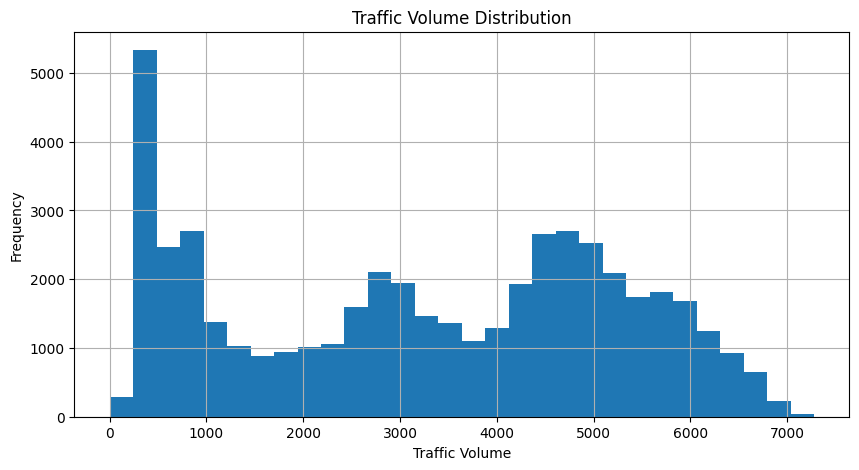

In [33]:
plt.figure(figsize=(10,5))

plt.hist(df["traffic_volume"], bins=30)

plt.title("Traffic Volume Distribution")

plt.xlabel("Traffic Volume")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

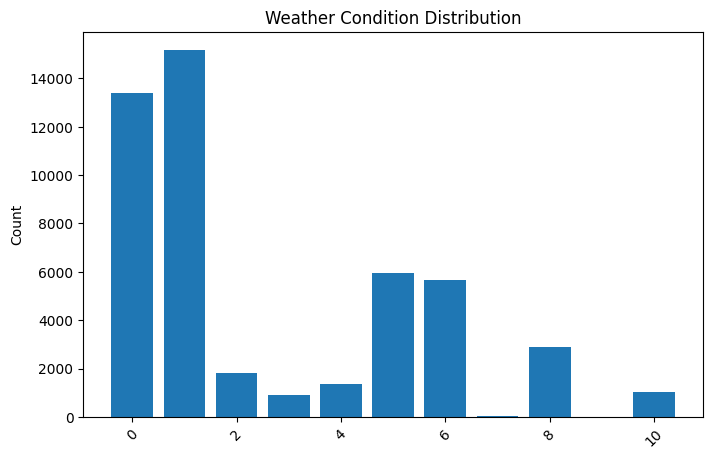

In [34]:
weather = df["weather_main"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    weather.index,
    weather.values
)

plt.xticks(rotation=45)

plt.title("Weather Condition Distribution")

plt.ylabel("Count")

plt.show()

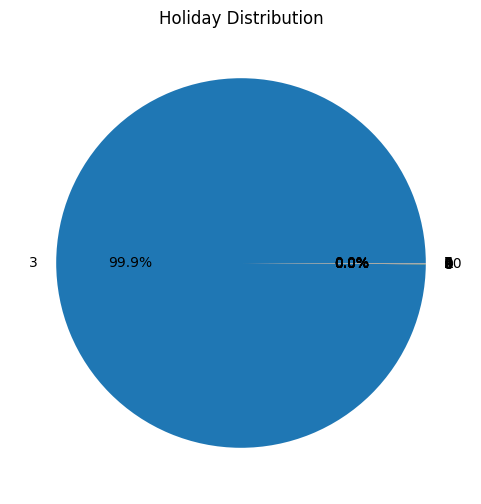

In [35]:
holiday = df["holiday"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    holiday.values,
    labels=holiday.index,
    autopct="%1.1f%%"
)

plt.title("Holiday Distribution")

plt.show()

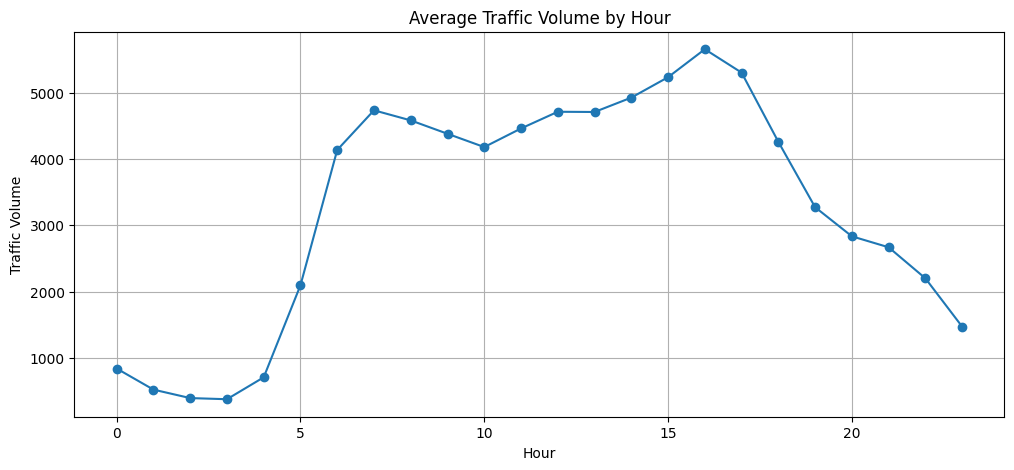

In [36]:
hourly = (
    df.groupby("hour")["traffic_volume"]
      .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    hourly.index,
    hourly.values,
    marker="o"
)

plt.title("Average Traffic Volume by Hour")

plt.xlabel("Hour")

plt.ylabel("Traffic Volume")

plt.grid(True)

plt.show()

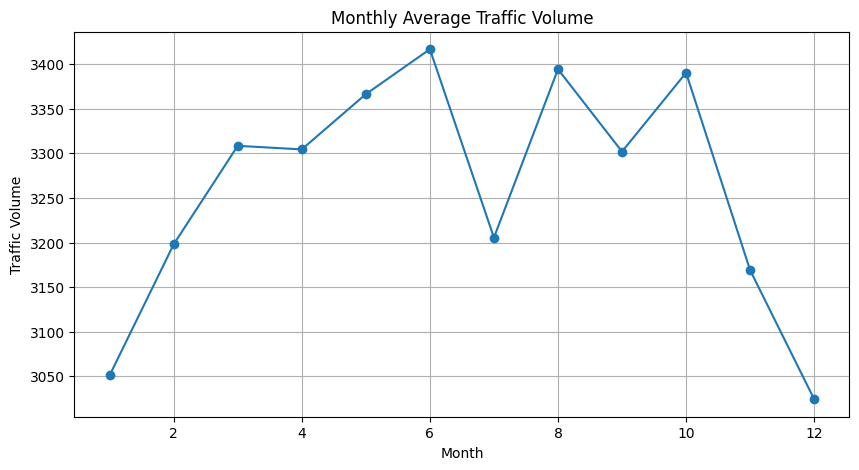

In [37]:
monthly = (
    df.groupby("month")["traffic_volume"]
      .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.title("Monthly Average Traffic Volume")

plt.xlabel("Month")

plt.ylabel("Traffic Volume")

plt.grid(True)

plt.show()

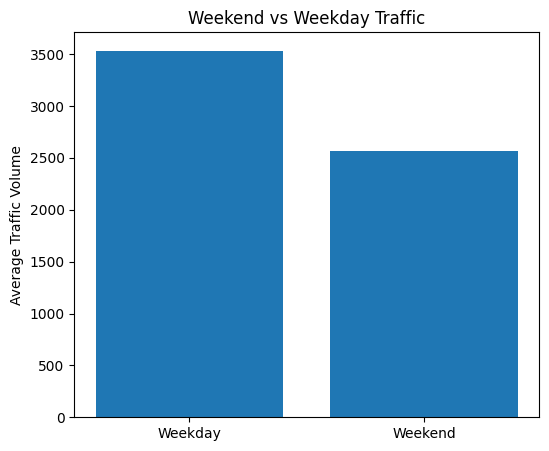

In [38]:
weekend = (
    df.groupby("is_weekend")["traffic_volume"]
      .mean()
)

plt.figure(figsize=(6,5))

plt.bar(
    ["Weekday","Weekend"],
    weekend.values
)

plt.title("Weekend vs Weekday Traffic")

plt.ylabel("Average Traffic Volume")

plt.show()

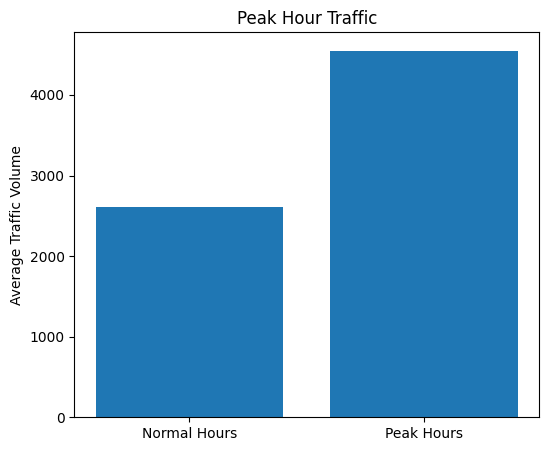

In [39]:
peak = (
    df.groupby("is_peak_hour")["traffic_volume"]
      .mean()
)

plt.figure(figsize=(6,5))

plt.bar(
    ["Normal Hours","Peak Hours"],
    peak.values
)

plt.title("Peak Hour Traffic")

plt.ylabel("Average Traffic Volume")

plt.show()

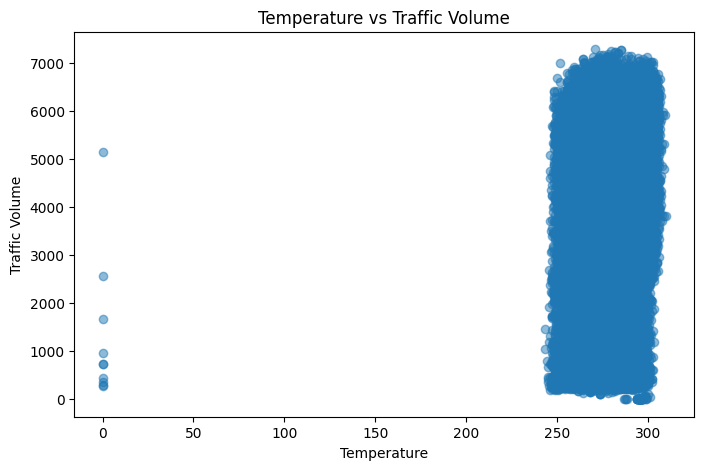

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["temp"],
    df["traffic_volume"],
    alpha=0.5
)

plt.xlabel("Temperature")

plt.ylabel("Traffic Volume")

plt.title("Temperature vs Traffic Volume")

plt.show()

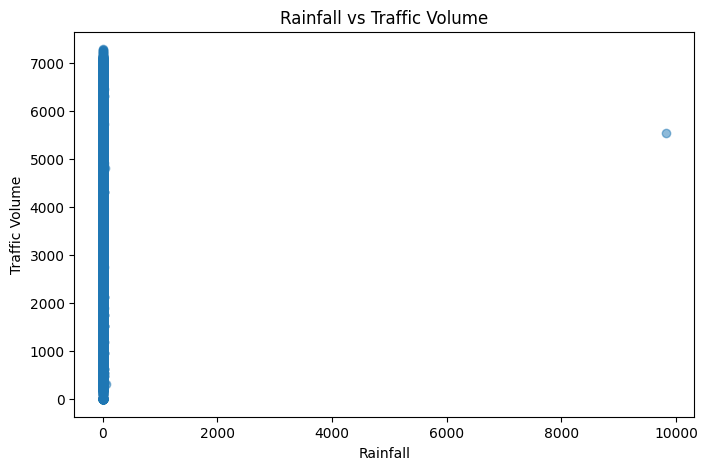

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["rain_1h"],
    df["traffic_volume"],
    alpha=0.5
)

plt.xlabel("Rainfall")

plt.ylabel("Traffic Volume")

plt.title("Rainfall vs Traffic Volume")

plt.show()

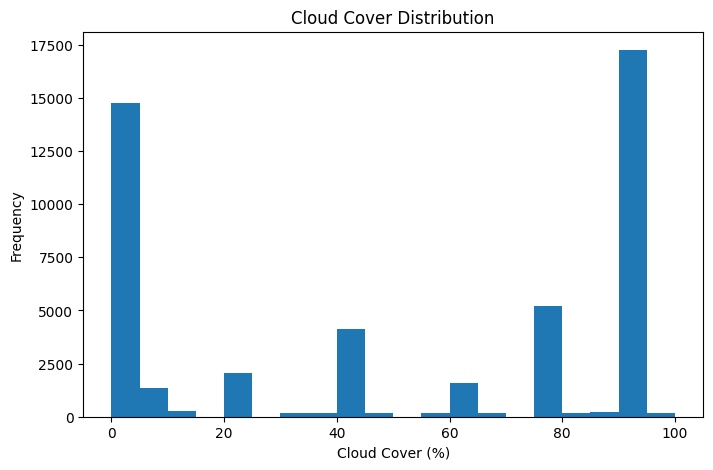

In [42]:
plt.figure(figsize=(8,5))

plt.hist(
    df["clouds_all"],
    bins=20
)

plt.title("Cloud Cover Distribution")

plt.xlabel("Cloud Cover (%)")

plt.ylabel("Frequency")

plt.show()

In [43]:
corr = df.corr(numeric_only=True)

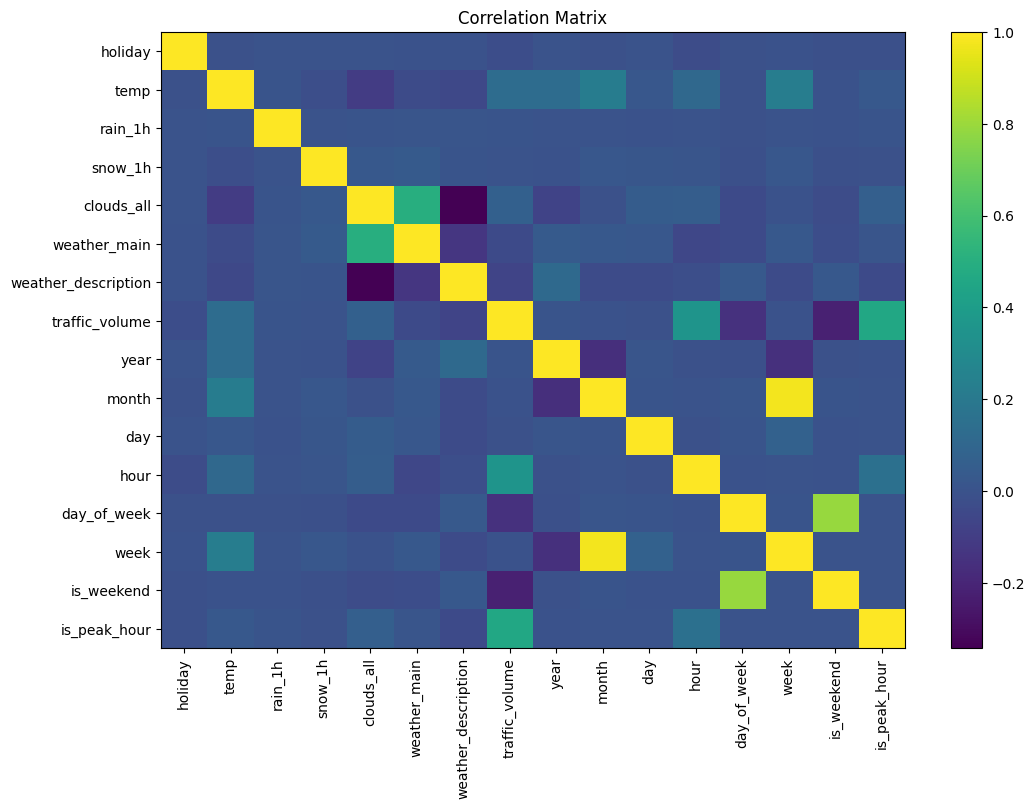

In [44]:
plt.figure(figsize=(12,8))

plt.imshow(
    corr,
    interpolation="nearest",
    aspect="auto"
)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

In [45]:
hourly_df = (
    df.groupby("hour")["traffic_volume"]
      .mean()
      .reset_index()
)

fig = px.line(
    hourly_df,
    x="hour",
    y="traffic_volume",
    title="Average Hourly Traffic Volume"
)

fig.show()

In [46]:
monthly_df = (
    df.groupby("month")["traffic_volume"]
      .mean()
      .reset_index()
)

fig = px.bar(
    monthly_df,
    x="month",
    y="traffic_volume",
    title="Monthly Traffic Volume"
)

fig.show()

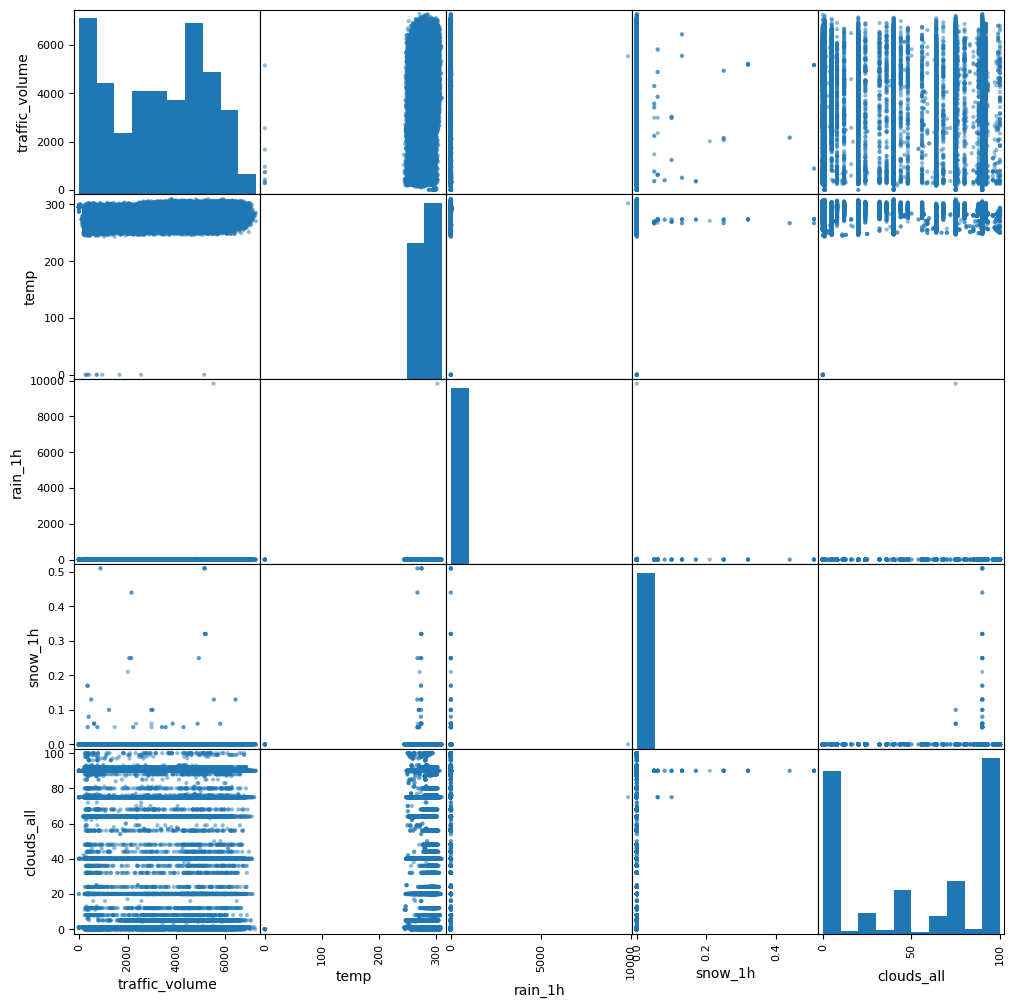

In [47]:
pd.plotting.scatter_matrix(
    df[
        [
            "traffic_volume",
            "temp",
            "rain_1h",
            "snow_1h",
            "clouds_all"
        ]
    ],
    figsize=(12,12)
)

plt.show()

In [48]:
df.to_csv(
    r"C:\AI-Powered-Intelligent-Traffic-Management-System\datasets\processed\traffic_ml_dataset.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


# EDA Insights

1. Traffic volume is highest during morning and evening peak hours.

2. Weekdays generally experience higher traffic than weekends.

3. Weather conditions influence traffic volume, especially during rain and snow.

4. Temperature shows a moderate relationship with traffic patterns.

5. Cloud cover has limited impact compared to holidays and peak hours.

6. Missing values and duplicate records were handled during preprocessing.

7. The dataset is clean and suitable for feature engineering and machine learning.

8. Time-based features such as hour, month, and weekday are expected to be strong predictors.

9. Traffic volume forecasting can benefit from historical temporal patterns combined with weather variables.